In [28]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow.keras as keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import mlflow
import optuna
from optuna.pruners import MedianPruner
import mlflow.tensorflow

In [29]:
import os
import mlflow

mlflow.set_tracking_uri('http://localhost:5001')
mlflow.set_experiment("brecha_regresion")

<Experiment: artifact_location=('/Users/santiagoquintana/Downloads/UNIANDES '
 'Local/M-IIND/2026-1/Analitic_comp/Proyecto2/ciencia_datos/ciencia_datosSQ/mlartifacts/1'), creation_time=1779737861150, experiment_id='1', last_update_time=1779737861150, lifecycle_stage='active', name='brecha_regresion', tags={}, trace_location=None, workspace='default'>

In [30]:
!pwd

/Users/santiagoquintana/Downloads/UNIANDES Local/M-IIND/2026-1/Analitic_comp/Proyecto2/ciencia_datos/ciencia_datosSQ


In [31]:
data = pd.read_csv('../../EDA/data_finalSQ.csv')

## Regresión para predecir brecha

In [32]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('brecha_mat_lec', axis=1), data['brecha_mat_lec'], test_size=0.2, random_state=42)

FEATURES_ESCALAR = [
    'fami_estratovivienda',
    'fami_educacionmadre',
    'fami_educacionpadre',
    'fami_cuartoshogar',
    'fami_personashogar',
    'punt_tecnologia',]

FEATURES_BINARIAS = ['cole_area_ubicacion']
FEATURES_EMBEDDING = ['cole_caracter', 'cole_jornada']

FEATURE_NAMES = FEATURES_ESCALAR + FEATURES_BINARIAS + FEATURES_EMBEDDING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[FEATURES_ESCALAR + FEATURES_BINARIAS+FEATURES_EMBEDDING])
X_test_scaled  = scaler.transform(X_test[FEATURES_ESCALAR + FEATURES_BINARIAS+FEATURES_EMBEDDING])

In [33]:
def construir_modelo(capas_neuronas=(64, 32), activacion="relu", optimizador="adam", dropout=0.2, lr=1e-3, batch_norm=True):
    
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # capas ocultas
    for n_neuronas in capas_neuronas:
        model.add(layers.Dense(n_neuronas, activation=activacion))
        if batch_norm:
            model.add(layers.BatchNormalization())
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    
    model.add(layers.Dense(1))
    
    optimizadores = {
        "adam":    keras.optimizers.Adam(learning_rate=lr),
        "sgd":     keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=lr),
        "adamw":   keras.optimizers.AdamW(learning_rate=lr),
    }
    opt = optimizadores.get(optimizador, keras.optimizers.Adam(learning_rate=lr))

    model.compile(optimizer=opt, loss="mse", metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")])
    return model

[I 2026-05-25 17:52:06,021] A new study created in memory with name: no-name-f2d89b16-7e51-4c25-9737-304fc12b33c7


  0%|          | 0/20 [00:00<?, ?it/s]

🏃 View run trial_00_l2_selu_adam at: http://localhost:5001/#/experiments/1/runs/2c60b7c790bd486483e08b67c428bf88
🧪 View experiment at: http://localhost:5001/#/experiments/1
[I 2026-05-25 17:52:38,288] Trial 0 finished with value: 65.86797332763672 and parameters: {'n_layers': 2, 'units_l0': 32, 'units_l1': 128, 'activacion': 'selu', 'optimizador': 'adam', 'dropout': 0.09170225492671691, 'lr': 0.0004059611610484307, 'batch_norm': True, 'batch_size': 256}. Best is trial 0 with value: 65.86797332763672.
🏃 View run trial_01_l2_selu_adam at: http://localhost:5001/#/experiments/1/runs/8e1a197a1fd64dc28e36951b6f068de2
🧪 View experiment at: http://localhost:5001/#/experiments/1
[I 2026-05-25 17:53:09,488] Trial 1 finished with value: 65.7932357788086 and parameters: {'n_layers': 2, 'units_l0': 128, 'units_l1': 256, 'activacion': 'selu', 'optimizador': 'adam', 'dropout': 0.048836057003191935, 'lr': 0.0023359635026261607, 'batch_norm': True, 'batch_size': 512}. Best is trial 1 with value: 65.793

/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5028
Received: inputs=['Tensor(shape=(1000, 9))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_5028
Received: inputs=['Tensor(shape=(50, 9))']
  warnings.warn(msg)
/var/folders/_2/mzpdbswd3cq_m_g4ggyf09700000gn/T/ipykernel_90194/3959822140.py:255: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled[:n_samples_shap], feature_names=FEATURE_NAMES, show=False)
/opt/anaconda3/lib/python3.11/site-packages/shap/plots/_beeswarm.py:723: FutureWarning

Calculados SHAP values para 1000 muestras


2026/05/25 18:02:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


  Test RMSE: 8.0381
  Test R²: 0.0187
  Sesgo: -0.0303
🏃 View run MEJOR_trial08_l3_elu_adam at: http://localhost:5001/#/experiments/1/runs/86f87580403d433db5f211fed1749939
🧪 View experiment at: http://localhost:5001/#/experiments/1


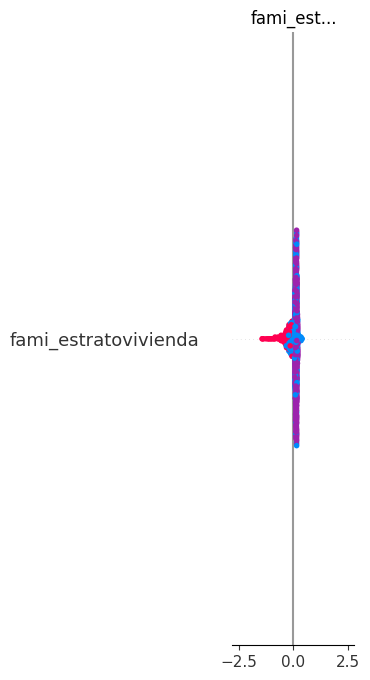

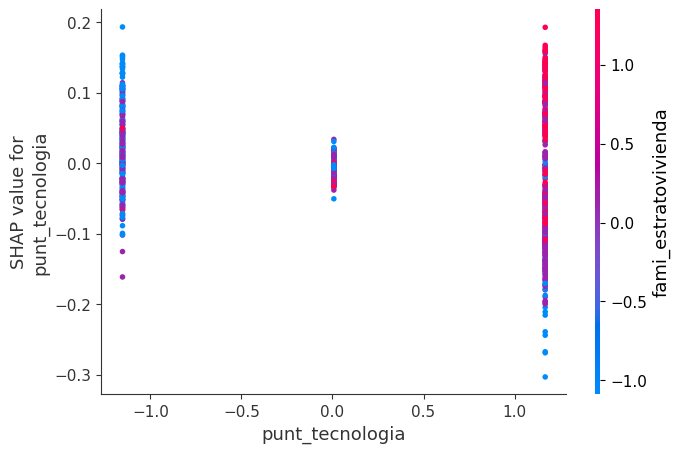

In [34]:
def objective(trial):
        
    n_layers = trial.suggest_int("n_layers", 1, 4)
    units_layers = [trial.suggest_categorical(f"units_l{i}", [32, 64, 128, 256]) for i in range(n_layers)]
    activacion = trial.suggest_categorical("activacion", ["relu", "elu", "selu"])
    optimizador_name = trial.suggest_categorical("optimizador", ["adam", "adamw", "rmsprop"])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_norm = trial.suggest_categorical("batch_norm", [True, False])
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
        
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    
    for units in units_layers:
        model.add(layers.Dense(units, activation=activacion))
        if batch_norm:
            model.add(layers.BatchNormalization())
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(1))
    
    optimizadores_dict = {
        "adam": keras.optimizers.Adam(learning_rate=lr),
        "adamw": keras.optimizers.AdamW(learning_rate=lr),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=lr),
    }
    
    model.compile(
        optimizer=optimizadores_dict[optimizador_name],
        loss="mse",
        metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
    )
    
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    
    val_loss = min(history.history["val_loss"])
        
    run_name = f"trial_{trial.number:02d}_l{n_layers}_{activacion}_{optimizador_name}"
    
    with mlflow.start_run(run_name=run_name, nested=True):    
        mlflow.log_params({
            "trial_number": trial.number,
            "n_layers": n_layers,
            **{f"units_l{i}": units_layers[i] for i in range(n_layers)},
            "activacion": activacion,
            "optimizador": optimizador_name,
            "dropout": dropout,
            "lr": lr,
            "batch_norm": batch_norm,
            "batch_size": batch_size,
        })
        
        mlflow.log_metrics({
            "val_loss_final": val_loss,
            "val_mae_final": history.history["val_mae"][-1],
            "train_loss_final": history.history["loss"][-1],
            "epochs_entrenados": len(history.history["loss"]),
        })
        
        y_pred_trial = model.predict(X_test_scaled, verbose=0).flatten()
        rmse_trial = np.sqrt(mean_squared_error(y_test, y_pred_trial))
        mae_trial = mean_absolute_error(y_test, y_pred_trial)
        r2_trial = r2_score(y_test, y_pred_trial)
        
        mlflow.log_metrics({
            "test_rmse": rmse_trial,
            "test_mae": mae_trial,
            "test_r2": r2_trial,
        })
    
    return val_loss

sampler = optuna.samplers.TPESampler(seed=42)
pruner = MedianPruner()
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

study.optimize(objective, n_trials=20, show_progress_bar=True)
best_trial = study.best_trial
best_params = best_trial.params
print(f"Mejor trial: #{best_trial.number}")
print(f"Mejor val_loss: {best_trial.value:.6f}")
print(f"\nMejores parámetros:")
for key, val in best_params.items():
    print(f"  {key}: {val}")

print(f"\nRe-entrenando mejor modelo (trial #{best_trial.number}) con todo el train...")

n_layers = best_params["n_layers"]
units_layers = [best_params[f"units_l{i}"] for i in range(n_layers)]
activacion = best_params["activacion"]
optimizador_name = best_params["optimizador"]
dropout = best_params["dropout"]
lr = best_params["lr"]
batch_norm = best_params["batch_norm"]
batch_size = best_params["batch_size"]

mejor_modelo = keras.Sequential()
mejor_modelo.add(layers.Input(shape=(X_train_scaled.shape[1],)))

for units in units_layers:
    mejor_modelo.add(layers.Dense(units, activation=activacion))
    if batch_norm:
        mejor_modelo.add(layers.BatchNormalization())
    if dropout > 0:
        mejor_modelo.add(layers.Dropout(dropout))

mejor_modelo.add(layers.Dense(1))

optimizadores_dict = {
    "adam": keras.optimizers.Adam(learning_rate=lr),
    "adamw": keras.optimizers.AdamW(learning_rate=lr),
    "rmsprop": keras.optimizers.RMSprop(learning_rate=lr),
}

mejor_modelo.compile(
    optimizer=optimizadores_dict[optimizador_name],
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
)

callbacks_final = [
    keras.callbacks.EarlyStopping(monitor="loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5, patience=5, min_lr=1e-6)
]

history_final = mejor_modelo.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=batch_size,
    callbacks=callbacks_final,
    verbose=0
)


run_name = f"MEJOR_trial{best_trial.number:02d}_l{n_layers}_{activacion}_{optimizador_name}"

with mlflow.start_run(run_name=run_name):
    mlflow.log_params({
        "best_trial": best_trial.number,
        "n_trials": 20,
        **best_params
    })
    
    y_pred = mejor_modelo.predict(X_test_scaled, verbose=0).flatten()
    residuos = y_test.values - y_pred
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / (y_test.values + 1e-7)))
    medae = np.median(np.abs(residuos))
    max_error = np.max(np.abs(residuos))
    bias = np.mean(residuos)
    pct_5 = 100 * np.sum(np.abs(residuos) < 5) / len(residuos)
    pct_10 = 100 * np.sum(np.abs(residuos) < 10) / len(residuos)
    
    mlflow.log_metrics({
        "test_rmse": rmse,
        "test_mae": mae,
        "test_r2": r2,
        "test_mape": mape,
        "test_medae": medae,
        "test_max_error": max_error,
        "test_bias": bias,
        "pct_dentro_5pts": pct_5,
        "pct_dentro_10pts": pct_10,
        "epochs_entrenados": len(history_final.history["loss"]),
        "best_train_loss": min(history_final.history["loss"]),
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_final.history["loss"], label="train")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_ylabel("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(history_final.history["mae"], label="train")
    axes[1].set_title("MAE")
    axes[1].set_ylabel("MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.suptitle(run_name)
    plt.tight_layout()
    mlflow.log_figure(fig, "01_curvas_training.png")
    plt.close(fig)
    
    fig2, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_test, y_pred, alpha=0.2, s=8, color="steelblue")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            "r--", linewidth=1.5, label="Predicción perfecta")
    ax.set_xlabel("Brecha real")
    ax.set_ylabel("Brecha predicha")
    ax.set_title(f"Real vs Predicho (R²={r2:.4f})")
    ax.legend()
    ax.grid(alpha=0.3)
    mlflow.log_figure(fig2, "02_real_vs_predicho.png")
    plt.close(fig2)
    
    fig3, ax = plt.subplots(figsize=(8, 5))
    ax.hist(residuos, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='r', linestyle='--', linewidth=2, label=f'Sesgo={bias:.4f}')
    ax.set_xlabel("Residuos (Real - Predicho)")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribución de Residuos")
    ax.legend()
    ax.grid(alpha=0.3)
    mlflow.log_figure(fig3, "03_residuos.png")
    plt.close(fig3)
    
    fig4, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(y_pred, residuos, alpha=0.3, s=8, color="steelblue")
    ax.axhline(0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel("Predicciones")
    ax.set_ylabel("Residuos")
    ax.set_title("Residuos vs Predicciones (Heterocedasticidad)")
    ax.grid(alpha=0.3)
    mlflow.log_figure(fig4, "04_residuos_vs_pred.png")
    plt.close(fig4)
        
    try:
        import shap

        background = X_train_scaled[:min(500, len(X_train_scaled))]
        print(f"\nUsando {len(background)} muestras como background para SHAP...")

        explainer = shap.GradientExplainer(mejor_modelo, background)

        n_samples_shap = min(1000, len(X_test_scaled))
        shap_values = explainer.shap_values(X_test_scaled[:n_samples_shap])

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        print(f"Calculados SHAP values para {n_samples_shap} muestras")

        fig_shap_summary = plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test_scaled[:n_samples_shap], feature_names=FEATURE_NAMES, show=False)
        mlflow.log_figure(fig_shap_summary, "05_shap_summary.png")
        plt.close(fig_shap_summary)

        try:
            idx_tech = FEATURE_NAMES.index("punt_tecnologia")
            idx_estrato = FEATURE_NAMES.index("fami_estratovivienda")

            fig_shap_dep = plt.figure(figsize=(10, 6))
            shap.dependence_plot(
                idx_tech,
                shap_values,
                X_test_scaled[:n_samples_shap],
                feature_names=FEATURE_NAMES,
                interaction_index=idx_estrato,
                show=False
            )
            mlflow.log_figure(fig_shap_dep, "06_shap_tech_vs_estrato.png")
            plt.close(fig_shap_dep)

        except Exception as e:
            print(f"Error en gráfica de moderación: {e}")
            idx_tech = FEATURE_NAMES.index("punt_tecnologia")
            fig_alt = plt.figure(figsize=(10, 6))
            shap.dependence_plot(idx_tech, shap_values, X_test_scaled[:n_samples_shap],
                                 feature_names=FEATURE_NAMES, show=False)
            mlflow.log_figure(fig_alt, "06_shap_punt_tecnologia.png")
            plt.close(fig_alt)


    except ImportError as e:
        print(f"\ Error: SHAP no disponible - {e}")
    except Exception as e:
        print(f"\nError en SHAP: {e}")
    
    mlflow.keras.log_model(mejor_modelo, artifact_path="modelo_optuna")

    print(f"  Test RMSE: {rmse:.4f}")
    print(f"  Test R²: {r2:.4f}")
    print(f"  Sesgo: {bias:.4f}")

import os
os.makedirs("reg_brecha", exist_ok=True)
mejor_modelo.save("reg_brecha/modelo_regresion.keras")

In [35]:
data

,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_cuartoshogar,fami_personashogar,cole_area_ubicacion,cole_caracter,cole_jornada,cole_naturaleza,brecha_mat_lec,punt_tecnologia
0,1.0,2.0,3.0,2.0,6.0,0,2.0,1,1,1.0,1
1,1.0,2.0,2.0,2.0,3.0,1,1.0,6,1,5.0,0
2,2.0,6.0,3.0,3.0,5.5,1,2.0,1,1,13.0,0
3,3.0,8.0,8.0,2.0,3.5,1,2.0,1,0,2.0,2
4,2.0,4.0,3.0,3.0,7.0,1,3.0,6,0,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...
93313,1.0,3.0,2.0,5.0,7.5,1,1.0,6,1,9.0,0
93314,1.0,1.0,1.0,3.0,6.0,0,3.0,1,1,3.0,0
93315,1.0,1.0,2.0,3.0,3.0,1,2.0,1,1,7.0,0
93316,2.0,4.0,2.0,3.0,4.0,0,3.0,2,1,0.0,0
